In [2]:
import scanpy as sc
import pandas as pd
import numpy as np


- filter genes not expressed at all/not in tf-gene prior
- filter TFs that are not really TFs
- filer TFs not expressed at all
- TF similarity
- do two times:
   - upper and lower bound on the number of targets for a TF (10, 80%)
   - filter lowly expressed genes
   - filter genes that do not have more than 5 TFs


In [3]:
adata=sc.datasets.visium_sge(sample_id="V1_Human_Lymph_Node")
adata.var_names_make_unique()
gene_means=adata.to_df().mean()

celltypes=pd.read_csv("https://raw.githubusercontent.com/vitkl/cell2location_paper/1c645a0519f8f27ecef18468cf339d35d99f42e7/notebooks/selected_results/lymph_nodes_analysis/CoLocationModelNB4V2_34clusters_4039locations_10241genes_input_inferred_V4_batch1024_l2_0001_n_comb50_5_cps5_fpc3_alpha001/W_cell_density.csv", index_col=0)
gc_annotation=pd.read_csv("https://raw.githubusercontent.com/vitkl/cell2location_paper/1c645a0519f8f27ecef18468cf339d35d99f42e7/notebooks/selected_results/lymph_nodes_analysis/CoLocationModelNB4V2_34clusters_4039locations_10241genes_input_inferred_V4_batch1024_l2_0001_n_comb50_5_cps5_fpc3_alpha001/manual_GC_annot.csv", index_col=0).fillna(0).replace("GC", 1)

obs_names=np.intersect1d(celltypes.index, adata.obs_names)
adata=adata[obs_names]
celltypes=celltypes.loc[obs_names]
gc_annotation=gc_annotation.loc[obs_names]
adata.obsm['celltype']=celltypes
adata.obsm['celltype'].columns=[x.replace('mean_spot_factors','') for x in adata.obsm['celltype'].columns]
adata.obsm['celltype_raw']=adata.obsm['celltype'].copy()
adata.obsm['celltype']=adata.obsm['celltype'].divide(adata.obsm['celltype'].sum(axis=1), axis=0)
adata.obs['germinal_center']=gc_annotation

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


... storing 'feature_types' as categorical
... storing 'genome' as categorical


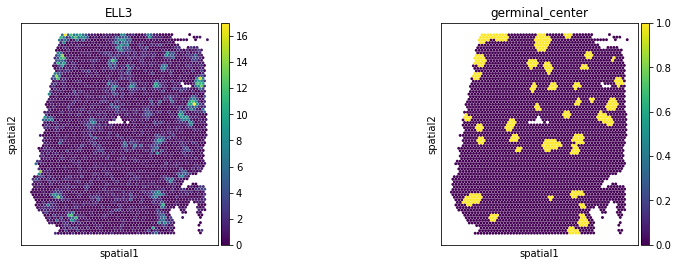

In [4]:
sc.pl.spatial(adata, color=["ELL3", "germinal_center"], alpha_img=0, size=1.5)

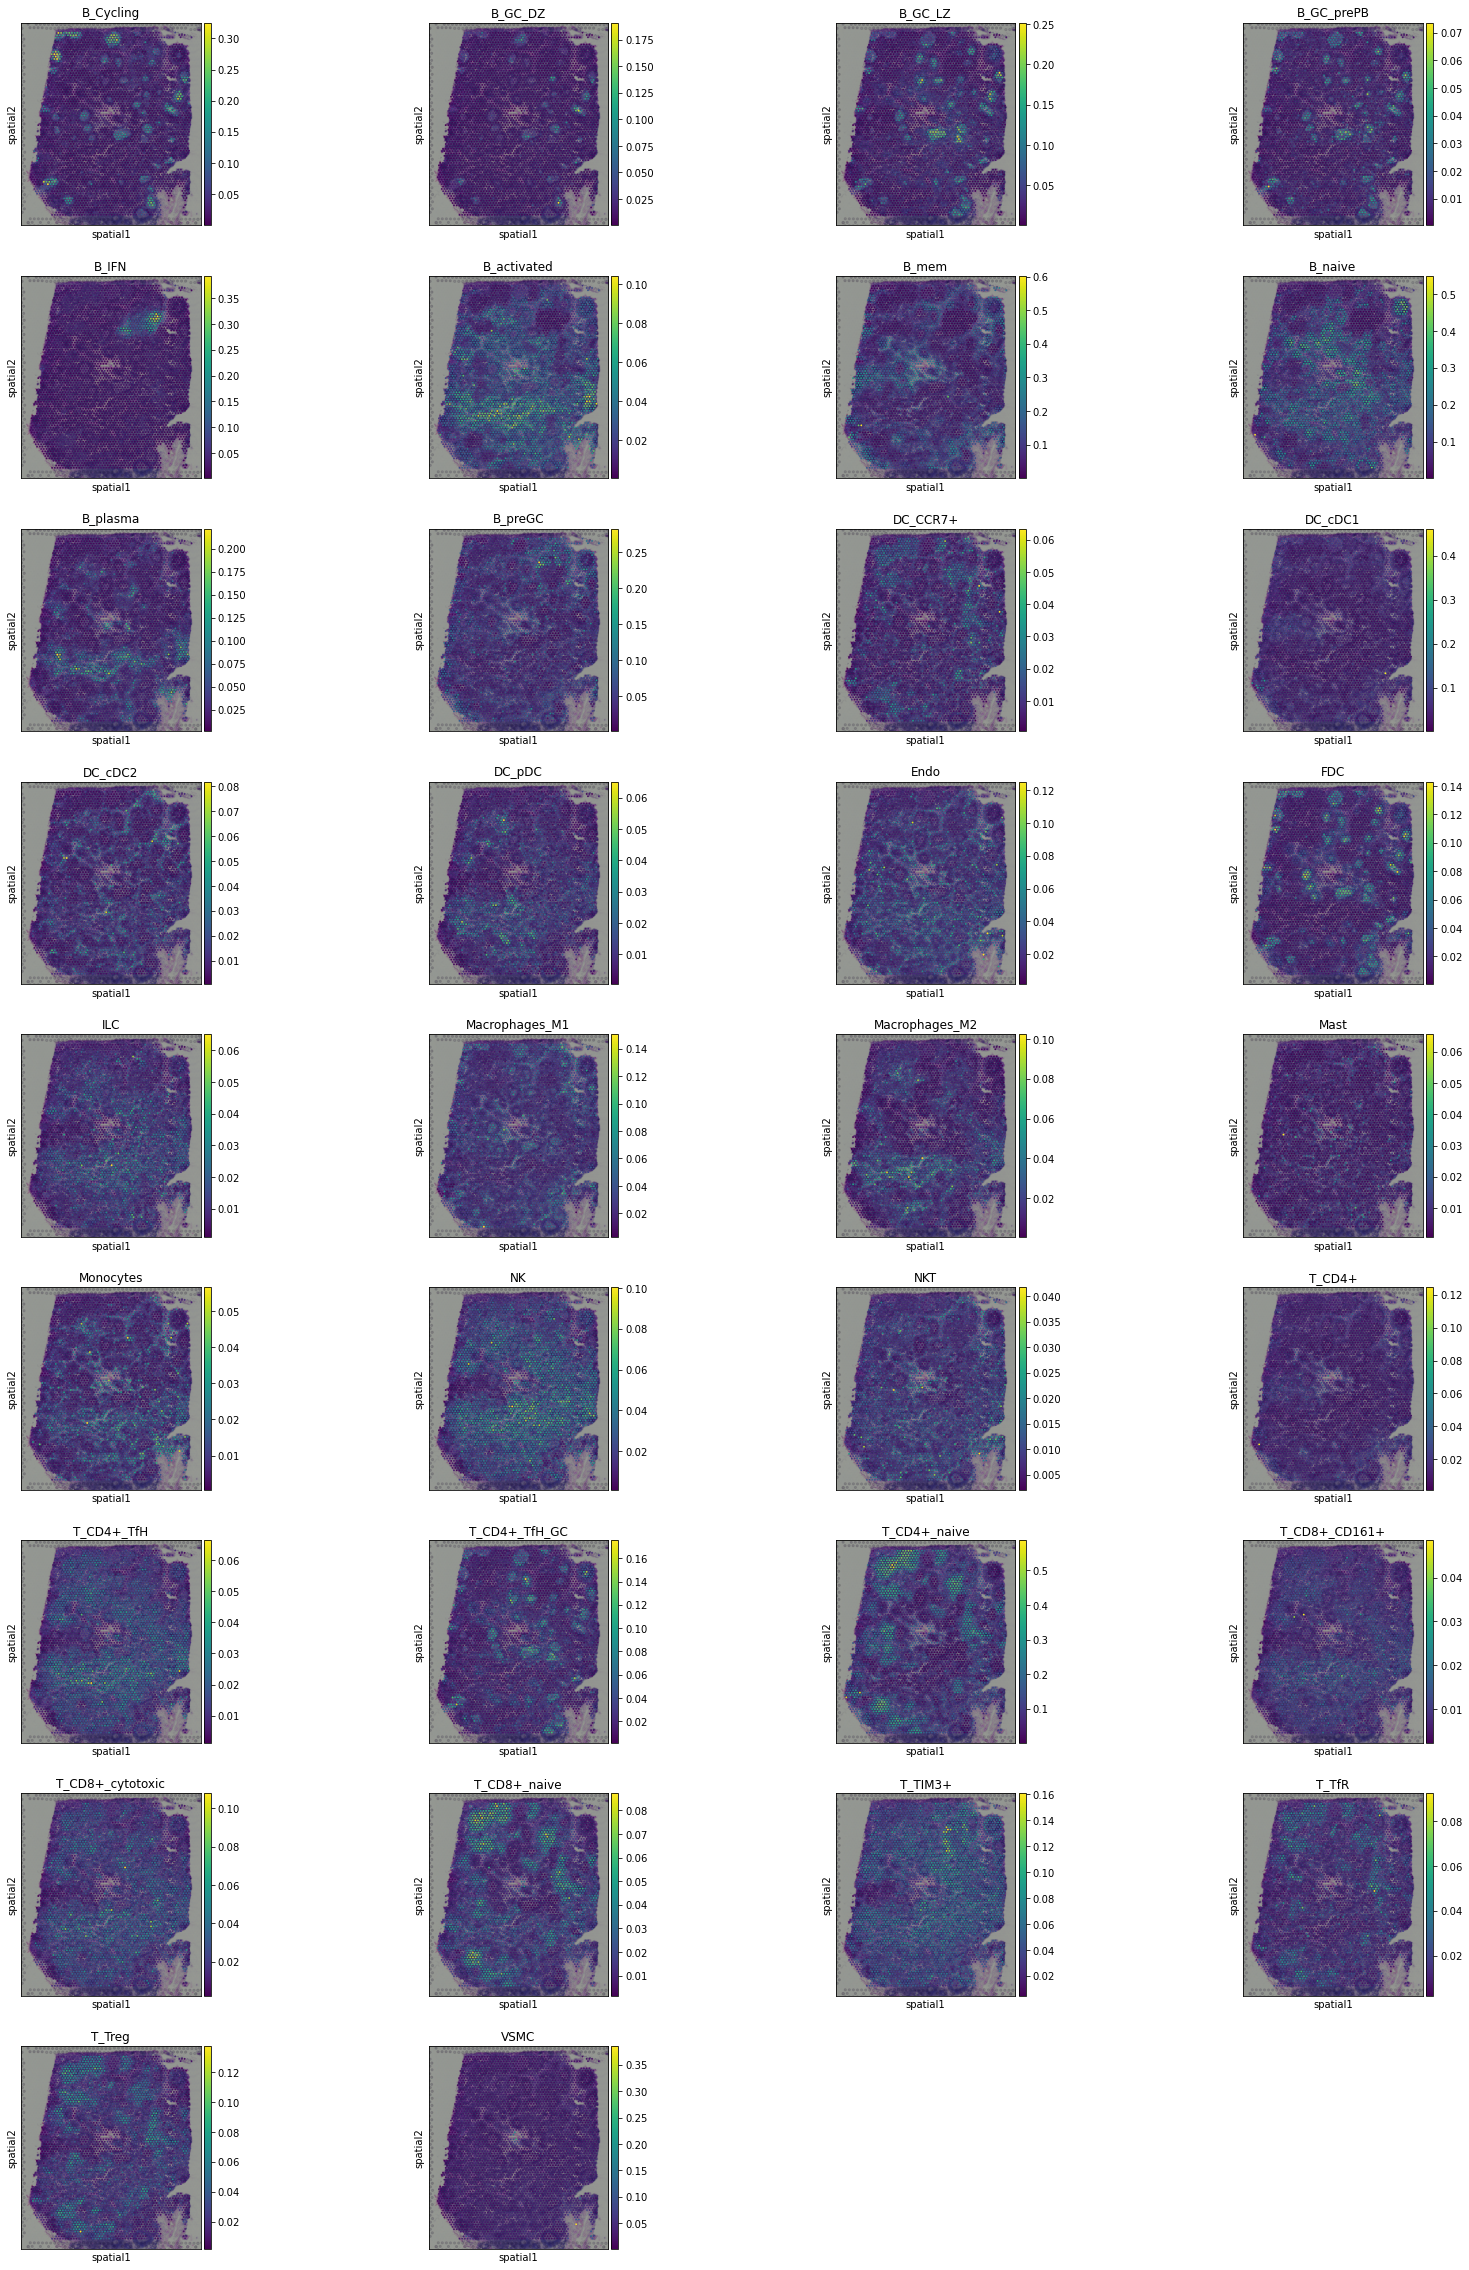

In [5]:
import squidpy as sq
sc.pl.spatial(sq.pl.extract(adata, obsm_key="celltype"), color=adata.obsm['celltype'].columns)

In [6]:
sc.pp.filter_genes(adata, min_cells=5)

In [7]:
!mkdir data/

mkdir: data/: File exists


In [8]:
adata.write("data/visium_lymph_node.h5ad")

In [9]:
adata

AnnData object with n_obs × n_vars = 4033 × 21261
    obs: 'in_tissue', 'array_row', 'array_col', 'germinal_center'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'celltype', 'celltype_raw'

In [10]:
ls

00_visium_lymph_node.ipynb*          darkzonelightzone.ipynb
10_stf.ipynb*                        data/
11_spatial_smoothing.ipynb           out/
20_clustering.ipynb                  ovarian_cancer_st_visualize.ipynb*
21_celltype_cors.ipynb               test_vst.ipynb
22_gc_differential_expression.ipynb  tf_names.ipynb
cell_type_scores.csv                 visium_lymph_node.h5ad
